### 工作進度  
* 新的筆記架構仍待定。構想如下：  
  - 第一部分：大盤解盤  
    * 『加權指數』與『櫃買指數』。  
      - 執行mysys.StockAnalysis類別的analysis方法  
        * 針對量化與ＡＩ分析結果加入個人觀點。  
        * 補充老師盤中資訊，來源於[日報](https://mega.nz/folder/a85wHKwK#SA6HACStdXRvMsLd2Ct0tQ)。這部份內容會隨著時間遞減，畢竟這方面的資料訂閱[K線追擊週報](https://smart.businessweekly.com.tw/e-subscription/project?c=GROUP00014146&p=PROD000019311)即可取得。    
    * 將老師手繪的趨勢線進行量化，使用mysys.DrawOnKlineChart函式。  
  - 第二部分：個股解盤  
    * **選股**來源  
      - 老師觀察股  
        * [K線追擊週報](https://smart.businessweekly.com.tw/e-subscription/project?c=GROUP00014146&p=PROD000019311)LINE群組  - 參閱[日報](https://mega.nz/folder/a85wHKwK#SA6HACStdXRvMsLd2Ct0tQ)。  
      - 自選觀察股  
        * [股票篩選器：中價位且平均趨向指標(ADX)上升穿越20](https://tw.tradingview.com/screener/FFH7FtPz/) 。  
    * 個股解盤  
      - 執行mysys.StockAnalysis類別的analysis方法。
      - 將老師手繪的趨勢線進行量化，使用mysys.DrawOnKlineChart函式。  
      - 補充籌碼面資訊：因為不是所有市場都有籌碼面資訊，因此很難透過AI進行分析，只能人工進行確認。
* 預計8月1日開始使用新的筆記架構，並重啟新的GitHub倉庫來做發佈。  

#### 引入模組與定義公用函式  
* 這部分在筆記架構中該如何定位？  

In [1]:
import numpy as np
import mysys
import markdown
import base64
from IPython.core.display import HTML

In [2]:
def stock_analysis( analysis, stock_id, buttom_pattern = False) :
    results,images = analysis.analysis(stock_id)
    if buttom_pattern is True and '底部型態' in images :
        print('底型反轉交易策略：')
        display(images['底部型態'])
    print('解盤內容：')
    if '整體評價' in images :
        display(images['整體評價'])
    result_md   = results.to_markdown(tablefmt="grid")
    result_html = markdown.markdown(result_md, extensions=['markdown_grid_tables:GridTableExtension'])
    display(HTML(result_html))

In [3]:
#### 建立「解盤」物件    

In [4]:
analysis = mysys.StockAnalysis()

### 大盤解盤  

* 加權指數  

解盤內容：


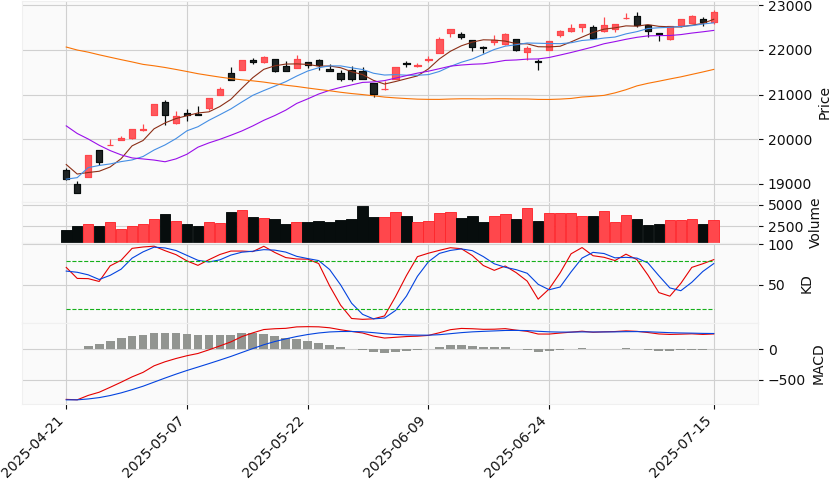

技術分析工具,解盤內容
Ｋ線／Ｋ棒,吞噬 : 2025-07-09 孕育線／懷抱線 : 2025-07-14
Ｋ線圖,中期為高位階 長期為中位階
成交量,價量關係：未至大量門檻（成交量 ＝ 3198.71億元 ，十日均量 ＝ 3160.46億元）
型態,反轉型態之三重頂，型態範圍由2024-08-12開始到2025-03-03結束，估算目標價為21371.24。 底型反轉之底部型態，型態範圍由2025-04-02開始到2025-05-02結束，估算目標價為22257.56。
移動平均線,5日線上揚、10日線上揚，短期翻多；20日線上揚、60日線上揚，中期翻多；120日線下彎、240日線下彎，長期翻空
ＫＤ指標,於2025-07-10黃金交叉。
ＭＡＣＤ指標,MACD在零軸以上，中期多方
周Ｋ－周ＫＤ指標,於2025-06-23當周黃金交叉。並且2025-07-07該周在超買區。
整體評價,"價格趨勢 目前價格呈現上漲趨勢。K線圖顯示近期紅K線較多，且價格持續在5日和10日移動平均線之上，顯示短期趨勢向上。 價量關係 成交量在上漲時有所增加，顯示多頭動能較強，價量配合良好。這種情況通常支持價格進一步上漲。 支撐與壓力判斷 - 支撐位置：短期支撐在10日移動平均線附近，約在22,500點。 - 壓力位置：上方壓力在近期高點23,000點附近。 KD指標解讀 KD指標顯示K線已進入超買區域，且高於D線，顯示短期內可能有回檔壓力，但目前多頭趨勢仍然強勁。 MACD指標解讀 MACD指標中，DIF線在MACD線之上，且灰色柱體為正，顯示多頭趨勢持續，動能增強。 綜合評價 整體來看，市場目前處於多頭趨勢，短期內可能會有小幅回檔，但整體上漲趨勢未改。建議投資者可考慮在回檔時進行佈局，並注意23,000點的壓力位，若突破此壓力，則有望進一步上行。停損可設在22,500點附近，以控制風險。"


In [5]:
stock_analysis(analysis,'TAIEX')

加權指數開在平盤附近：  
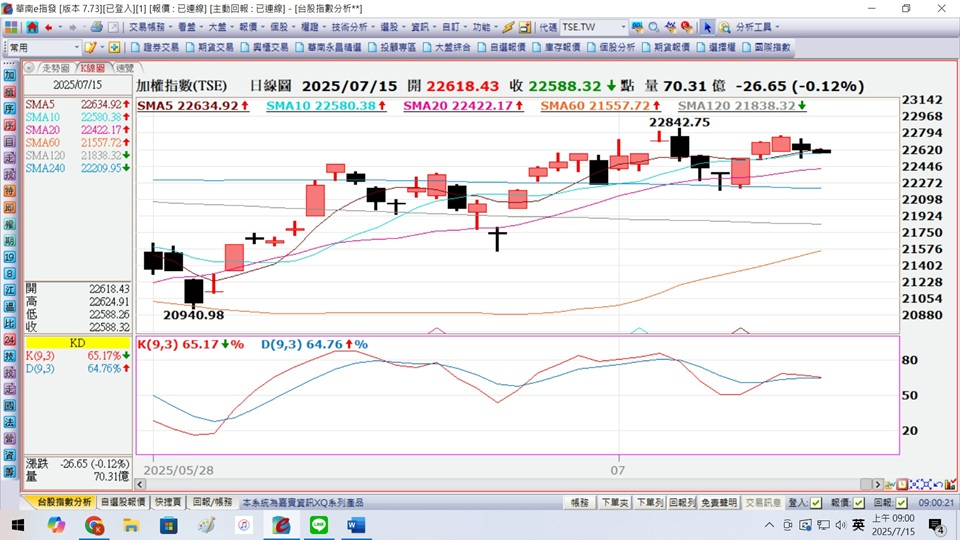  

很多投資人看到今天指數過高，會變得很樂觀，當然也有部分個股單兵點火，但其實整體還是在上升楔形之中，重點是預估量能大約只有3100億，不是突破量。  
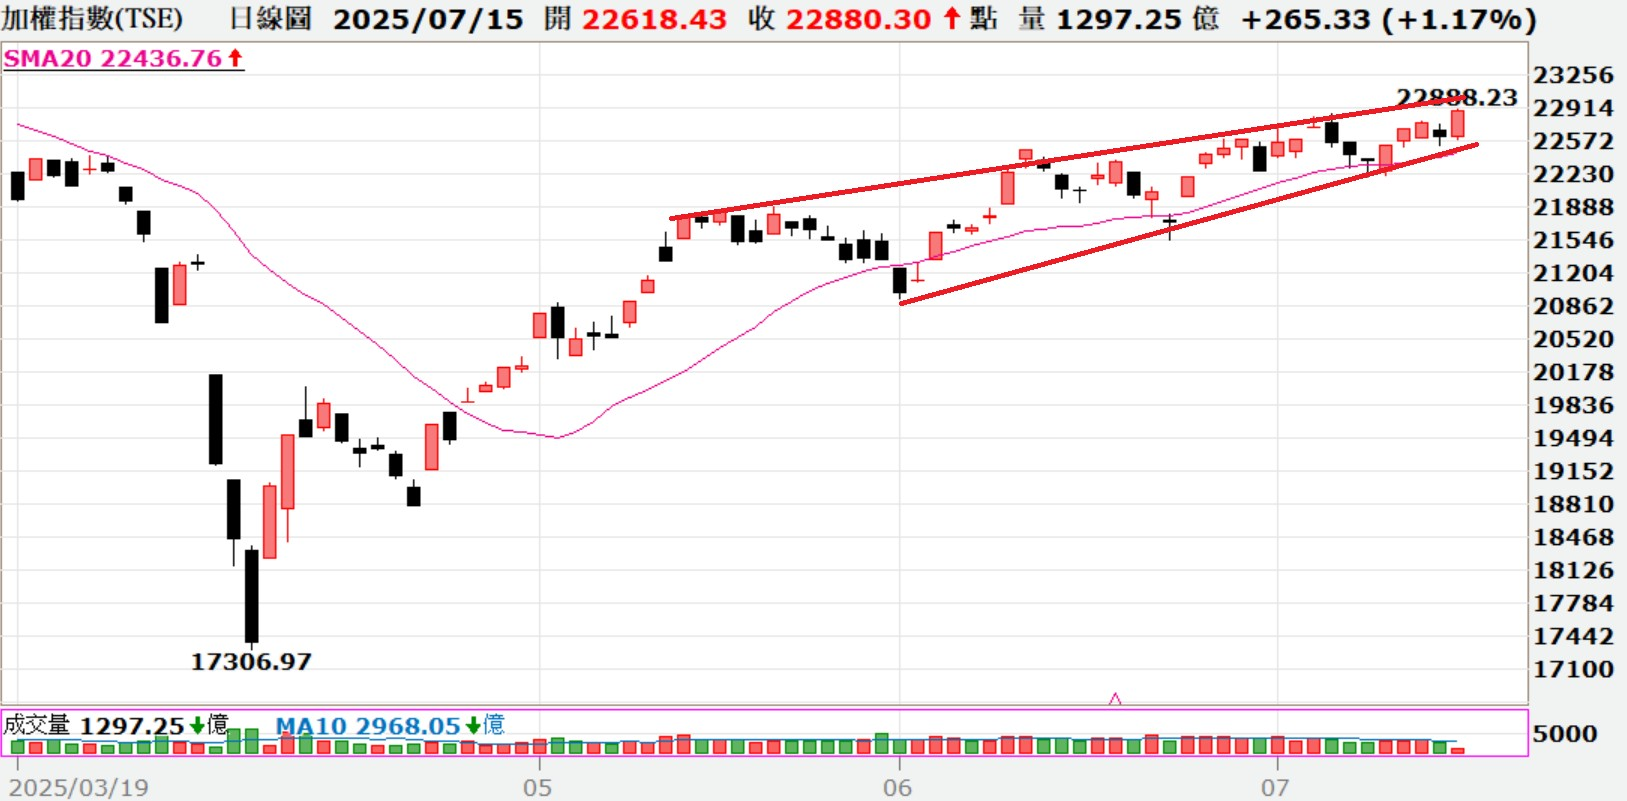  

In [6]:
def line_drawing_callback( range_prices) :
    # 設定楔形壓力線
    resistance_line_start_date  = '2025-05-14'
    resistance_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    resistance_line_x           = [mysys.DateToIndex(range_prices,'2025-05-16'),mysys.DateToIndex(range_prices,'2025-07-04')]
    resistance_line_y           = [range_prices.loc['2025-05-16']['Close'],range_prices.loc['2025-07-04']['Open']]
    slope,intercept             = np.polyfit(resistance_line_x,resistance_line_y,1)
    resistance_line_start_price = slope * mysys.DateToIndex(range_prices,resistance_line_start_date) + intercept
    resistance_line_end_price   = slope * mysys.DateToIndex(range_prices,resistance_line_end_date) + intercept

    # 設定楔形支撐線
    support_line_start_date  = '2025-06-02'
    support_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    support_line_x           = [mysys.DateToIndex(range_prices,'2025-06-02'),mysys.DateToIndex(range_prices,'2025-07-09')]
    support_line_y           = [range_prices.loc['2025-06-02']['Low'],(range_prices.loc['2025-07-08']['Close'] + range_prices.loc['2025-07-09']['Open'])/2]
    slope,intercept          = np.polyfit(support_line_x,support_line_y,1)
    support_line_start_price = slope * mysys.DateToIndex(range_prices,support_line_start_date) + intercept
    support_line_end_price   = slope * mysys.DateToIndex(range_prices,support_line_end_date) + intercept

    seq_of_seq_of_points=[
        [(resistance_line_start_date,resistance_line_start_price),(resistance_line_end_date,resistance_line_end_price)],
        [(support_line_start_date,support_line_start_price),(support_line_end_date,support_line_end_price)]
    ]

    linewidths=[1.5,1.5]
    
    colors=['xkcd:red','xkcd:red']

    return seq_of_seq_of_points,linewidths,colors

In [7]:
image = mysys.DrawOnKlineChart('TAIEX','2025-03-19','2025-07-15',line_drawing_callback)

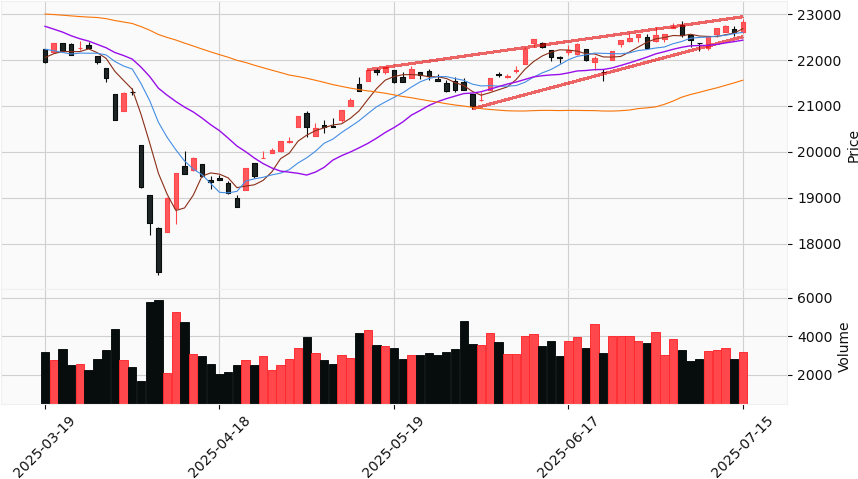

In [8]:
display(image)

* 櫃買指數  

解盤內容：


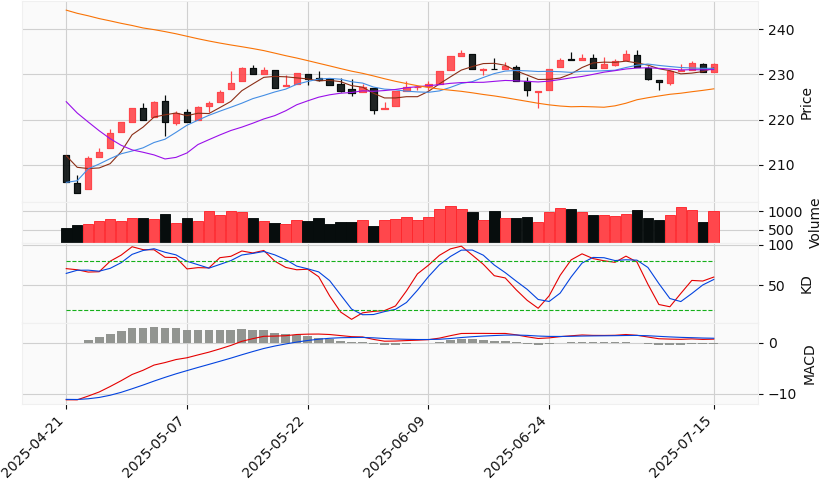

技術分析工具,解盤內容
Ｋ線／Ｋ棒,吞噬 : 2025-07-09
Ｋ線圖,中期為中位階 長期為中位階
成交量,價量關係：未至大量門檻（成交量 ＝ 1015.29億元 ，十日均量 ＝ 924.72億元）
型態,盤整型態之三角形，型態範圍由2024-07-11開始到2025-03-28結束。 底型反轉之底部型態，型態範圍由2025-04-02開始到2025-05-02結束，估算目標價為247.79。
移動平均線,5日線上揚、10日線上揚，短期翻多；20日線上揚、60日線上揚，中期翻多；120日線下彎、240日線下彎，長期翻空
ＫＤ指標,於2025-07-10黃金交叉。
ＭＡＣＤ指標,MACD在零軸以上，中期多方
周Ｋ－周ＫＤ指標,於2025-06-02當周死亡交叉。
整體評價,價格趨勢 目前價格處於盤整階段。K線圖顯示價格在230點附近波動，短期移動平均線（5日、10日）與中期移動平均線（20日、60日）糾結，顯示出市場缺乏明顯的方向性。 價量關係 成交量在近期有些許增加，但未顯著突破，顯示出市場參與者的觀望情緒。價量配合不明顯，無法確認多頭或空頭趨勢。 支撐與壓力 支撐位置大約在220點，壓力位置在240點。價格在這兩個區間內波動，需觀察是否有突破的跡象。 KD指標解讀 KD指標顯示K線與D線在50以上，且K線略高於D線，顯示出市場有些許的上行動能，但尚未進入超買區，需觀察後續是否能持續上行。 MACD指標解讀 MACD指標中，DIF線與MACD線接近零軸，且灰色柱體（OSC）變化不大，顯示出市場動能不足，短期內可能維持盤整。 綜合評價 整體來看，市場目前處於盤整狀態，短期內缺乏明顯的趨勢方向。建議投資者保持觀望，等待價格突破支撐或壓力位置後再行操作。若價格突破240點，可能會有進一步上行空間；若跌破220點，則需考慮停損策略。


In [9]:
stock_analysis(analysis,'TPEx')

櫃買指數也是變化不大：  
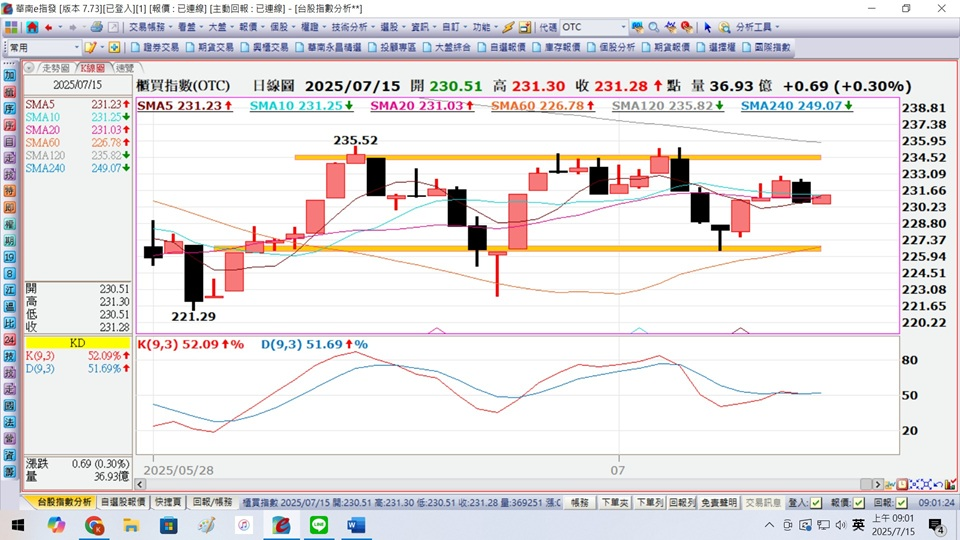  

In [10]:
def line_drawing_callback( range_prices) :
    # 設定箱型壓力線
    resistance_line_start_date  = '2025-06-09'
    resistance_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    resistance_line_price       = range_prices.loc['2025-07-03']['Close']

    # 設定箱型支撐線
    support_line_start_date  = '2025-06-03'
    support_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    support_line_price       = range_prices.loc['2025-06-24']['Open']

    seq_of_seq_of_points=[
        [(resistance_line_start_date,resistance_line_price),(resistance_line_end_date,resistance_line_price)],
        [(support_line_start_date,support_line_price),(support_line_end_date,support_line_price)]
    ]

    linewidths=[5.0,6.0]
    
    colors=['xkcd:orange yellow','xkcd:orange yellow']

    return seq_of_seq_of_points,linewidths,colors

In [11]:
image = mysys.DrawOnKlineChart('TPEx','2025-05-28','2025-07-15',line_drawing_callback)

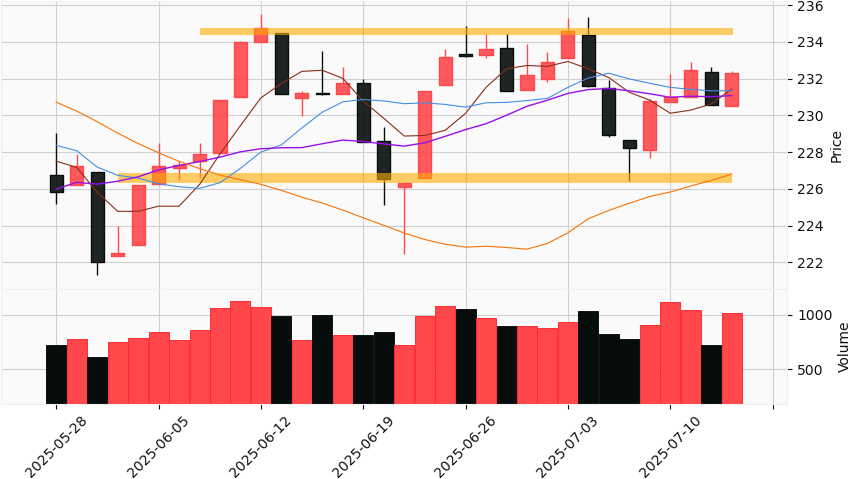

In [12]:
display(image)

### 個股解盤  

* 建漢(3062)  
  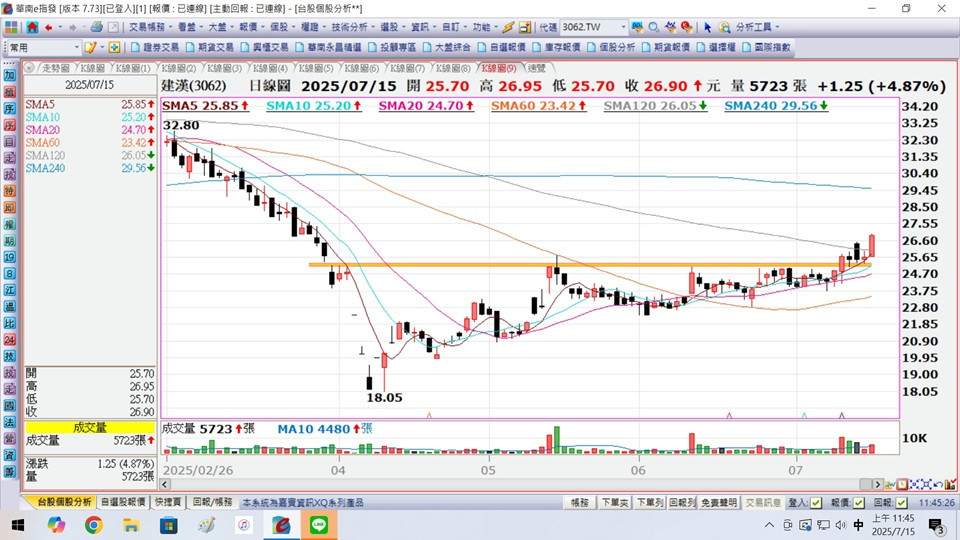  
  *反彈後續漲*。  

解盤內容：


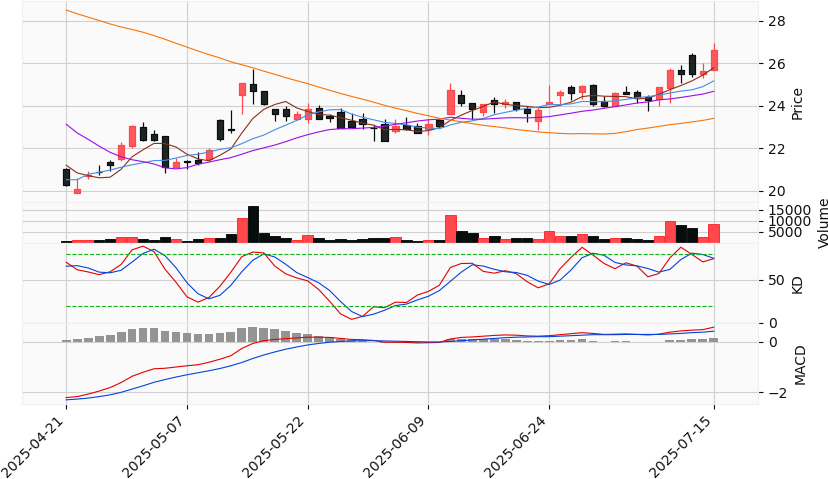

技術分析工具,解盤內容
Ｋ線／Ｋ棒,"紡錘線 : 2025-07-10 , 2025-07-14"
Ｋ線圖,中期為高位階 長期為中位階
成交量,價量關係：大型股爆量（成交量 ＝ 8798張 ，十日均量 ＝ 4787張）
型態,反轉型態之頭肩頂，型態範圍由2024-08-16開始到2025-03-13結束，估算目標價為19.77。 尚未成形底型反轉之底部型態，型態範圍由2025-03-28開始到2025-07-15結束。
移動平均線,5日線上揚、10日線上揚，短期翻多；20日線上揚、60日線上揚，中期翻多；120日線下彎、240日線下彎，長期翻空
ＫＤ指標,於2025-07-11死亡交叉。
ＭＡＣＤ指標,MACD在零軸以上，中期多方
周Ｋ－周ＫＤ指標,於2025-06-23當周黃金交叉。
整體評價,價格趨勢 目前股價呈現上漲趨勢。K線圖顯示近期紅K線較多，且股價已突破短期與中期移動平均線，尤其是5日與10日均線向上，顯示短期趨勢強勁。 價量關係 成交量在近期上漲過程中有所增加，尤其在突破時伴隨著較大的成交量，顯示多頭動能強勁，價量配合良好。 支撐與壓力 支撐位置可參考10日均線附近，約在26元左右。壓力位置則在28元附近，為近期高點。 KD指標解讀 KD指標顯示K線與D線在高檔區域，且K線略高於D線，顯示短期內仍有上漲動能，但需注意超買風險。 MACD指標解讀 MACD指標中，DIF線在MACD線之上，且灰色柱體為正值，顯示多頭趨勢明顯，短期內仍有上漲空間。 綜合評價 綜合以上分析，目前股價處於上漲趨勢，且價量配合良好，短期內有望繼續上行。然而，由於KD指標顯示超買，投資者需謹慎操作，建議在接近壓力位時考慮部分停利，並密切關注成交量變化以判斷趨勢是否持續。


In [13]:
stock_analysis(analysis,'3062')

In [14]:
def line_drawing_callback( range_prices) :
    # 設定頸線
    neckline_start_date = '2025-03-26'
    neckline_end_date   = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    neckline_price      = range_prices.loc['2025-05-14']['Close']

    seq_of_seq_of_points=[
        [(neckline_start_date,neckline_price),(neckline_end_date,neckline_price)]
    ]

    linewidths=[2.0]
    
    colors=['xkcd:orange yellow','xkcd:orange yellow']

    return seq_of_seq_of_points,linewidths,colors

In [15]:
image = mysys.DrawOnKlineChart('3062','2025-02-26','2025-07-15',line_drawing_callback)

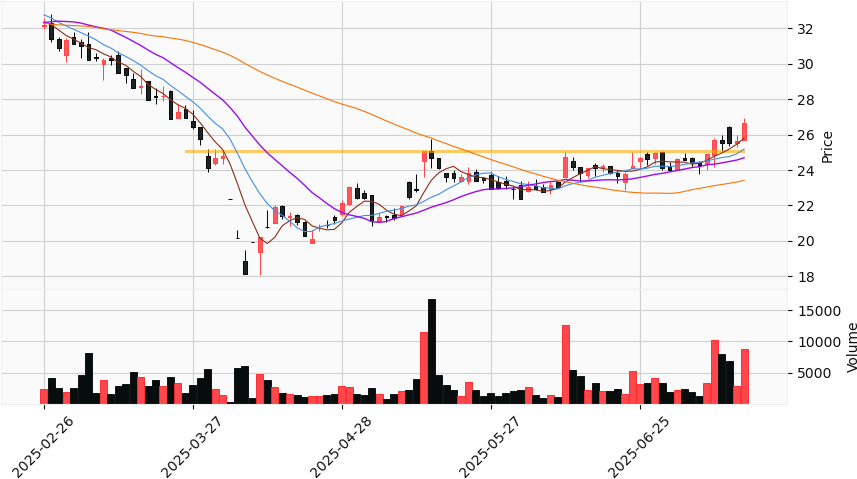

In [16]:
display(image)